# Pipeline Exploration

This notebook now uses the package-level pipeline in `src/uno_vision/`.
It is meant for quick end-to-end debugging: one crop-level classifier check, one scene-level segmentation view, and one full card prediction pass.

In [1]:
import sys
from pathlib import Path

PROJECT_ROOT = Path.cwd().resolve()
while not (PROJECT_ROOT / "src").exists() and PROJECT_ROOT.parent != PROJECT_ROOT:
    PROJECT_ROOT = PROJECT_ROOT.parent
if str(PROJECT_ROOT / "src") not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT / "src"))

import cv2
import matplotlib.pyplot as plt
import numpy as np

from uno_vision.classification.predict import load_card_classifier
from uno_vision.paths import AUGMENTATIONS_DIR, TEST_IMAGES_DIR
from uno_vision.pipeline.cards import predict_cards_in_image
from uno_vision.segmentation.inference import segment_image_path

print(f"Project root: {PROJECT_ROOT}")
print(f"Test images: {TEST_IMAGES_DIR}")

Project root: C:\Users\doria\Documents\EPFL\IA\iapr2026do\projodo
Test images: C:\Users\doria\Documents\EPFL\IA\iapr2026do\projodo\data\raw\test_images


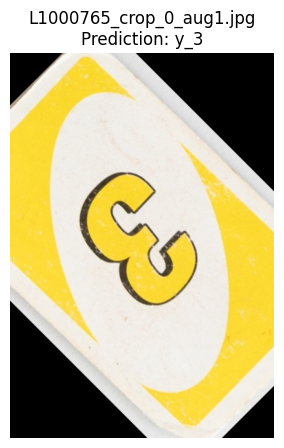

CardPrediction(label='y_3', color='y', rank='3')


In [2]:
classifier = load_card_classifier()
crop_candidates = sorted((AUGMENTATIONS_DIR / "images").glob("*.jpg"))
if not crop_candidates:
    raise FileNotFoundError(f"No augmentation images found in {AUGMENTATIONS_DIR / 'images'}")

crop_path = crop_candidates[0]
crop_bgr = cv2.imread(str(crop_path), cv2.IMREAD_COLOR)
crop_rgb = cv2.cvtColor(crop_bgr, cv2.COLOR_BGR2RGB)
crop_prediction = classifier.predict_bgr(crop_bgr)

plt.figure(figsize=(5, 5))
plt.imshow(crop_rgb)
plt.title(f"{crop_path.name}\nPrediction: {crop_prediction.label}")
plt.axis("off")
plt.show()

print(crop_prediction)

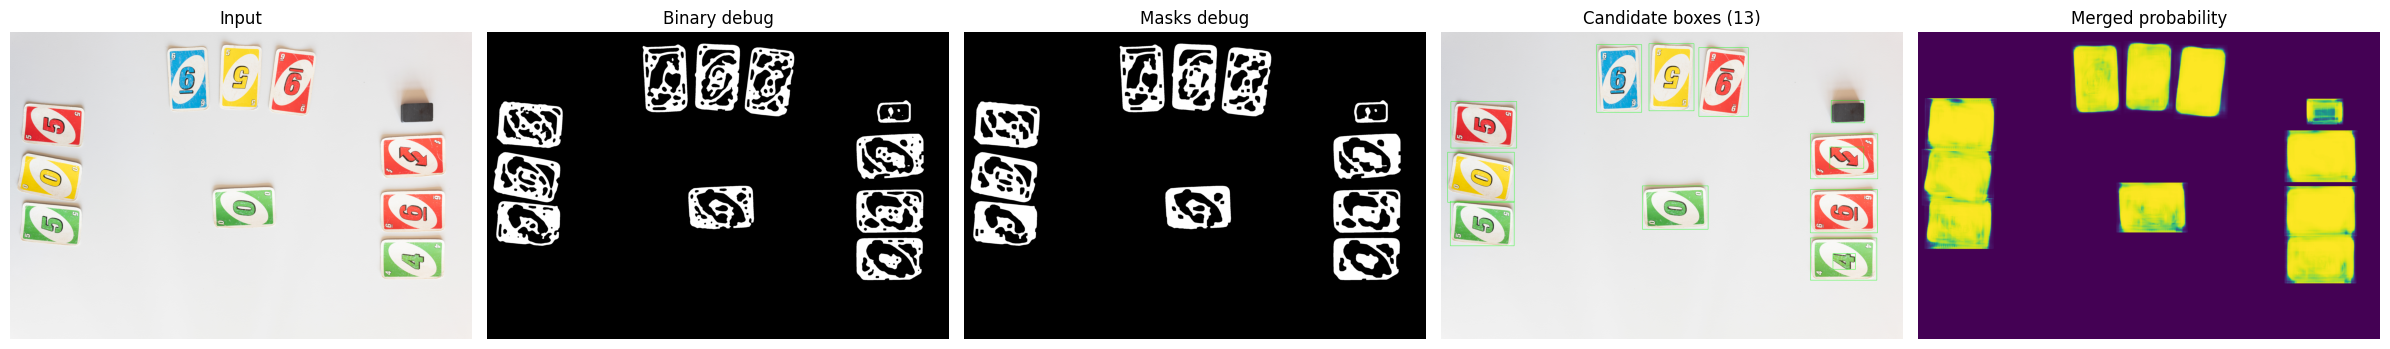

Segmenter model: C:\Users\doria\Documents\EPFL\IA\iapr2026do\projodo\artifacts\models\segmenter\segmenter_unet_small.pth
Scene image: C:\Users\doria\Documents\EPFL\IA\iapr2026do\projodo\data\raw\test_images\L1000793.jpg


In [3]:
scene_path = TEST_IMAGES_DIR / "L1000793.jpg"
img_bgr, global_prob, boxes, binary_dbg, masks_dbg, model_path = segment_image_path(scene_path)
img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
boxed = img_rgb.copy()
for x, y, w, h in boxes:
    cv2.rectangle(boxed, (x, y), (x + w, y + h), (0, 255, 0), 2)

fig, axes = plt.subplots(1, 5, figsize=(24, 5))
axes[0].imshow(img_rgb)
axes[0].set_title("Input")
axes[0].axis("off")

axes[1].imshow(binary_dbg, cmap="gray")
axes[1].set_title("Binary debug")
axes[1].axis("off")

axes[2].imshow(masks_dbg, cmap="gray")
axes[2].set_title("Masks debug")
axes[2].axis("off")

axes[3].imshow(boxed)
axes[3].set_title(f"Candidate boxes ({len(boxes)})")
axes[3].axis("off")

axes[4].imshow(global_prob, cmap="viridis")
axes[4].set_title("Merged probability")
axes[4].axis("off")

plt.tight_layout()
plt.show()

print(f"Segmenter model: {model_path}")
print(f"Scene image: {scene_path}")

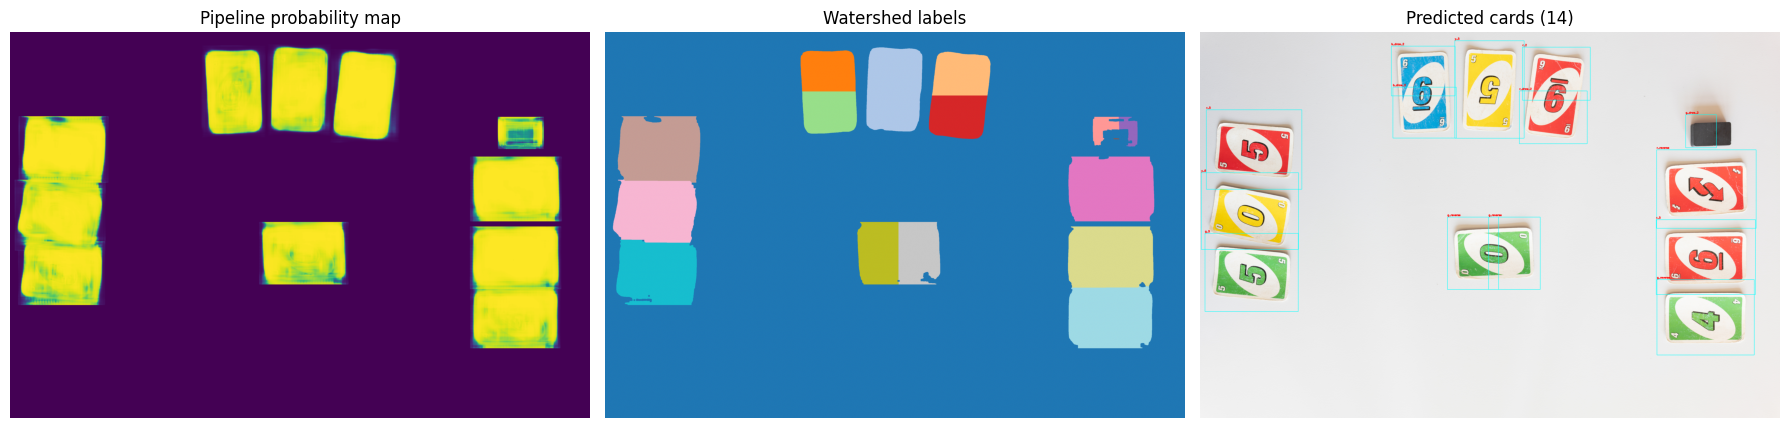

Predictions:
  00 | label=r_reverse    color=r          rank=reverse    box=(3149, 812, 3835, 1353) area=254652
  01 | label=r_5          color=r          rank=5          box=(3146, 1294, 3830, 1810) area=240982
  02 | label=r_5          color=r          rank=5          box=(43, 536, 702, 1084) area=237761
  03 | label=g_reverse    color=g          rank=reverse    box=(3151, 1707, 3822, 2227) area=233839
  04 | label=g_5          color=g          rank=5          box=(34, 1388, 677, 1927) area=224198
  05 | label=y_6          color=y          rank=6          box=(9, 970, 679, 1499) area=222965
  06 | label=y_5          color=y          rank=5          box=(1757, 60, 2235, 732) area=205854
  07 | label=g_reverse    color=g          rank=reverse    box=(1706, 1276, 2059, 1775) area=117090
  08 | label=g_reverse    color=g          rank=reverse    box=(1990, 1276, 2346, 1775) area=115295
  09 | label=r_2          color=r          rank=2          box=(2223, 104, 2691, 470) area=108665
  10 

In [4]:
predictions, pipeline_prob, ws_labels = predict_cards_in_image(scene_path)
vis = img_rgb.copy()

for prediction in predictions:
    x0, y0, x1, y1 = prediction.box
    cv2.rectangle(vis, (x0, y0), (x1, y1), (0, 255, 255), 2)
    cv2.putText(
        vis,
        prediction.label,
        (x0, max(20, y0 - 8)),
        cv2.FONT_HERSHEY_SIMPLEX,
        0.6,
        (255, 0, 0),
        2,
        cv2.LINE_AA,
    )

fig, axes = plt.subplots(1, 3, figsize=(18, 6))
axes[0].imshow(pipeline_prob, cmap="viridis")
axes[0].set_title("Pipeline probability map")
axes[0].axis("off")

axes[1].imshow(ws_labels, cmap="tab20")
axes[1].set_title("Watershed labels")
axes[1].axis("off")

axes[2].imshow(vis)
axes[2].set_title(f"Predicted cards ({len(predictions)})")
axes[2].axis("off")

plt.tight_layout()
plt.show()

print("Predictions:")
for prediction in predictions:
    print(
        f"  {prediction.index:02d} | label={prediction.label:<12} "
        f"color={prediction.color:<10} rank={prediction.rank:<10} box={prediction.box} area={prediction.area}"
    )